In [1]:
import sys
sys.path.append('/cluster/home/taoj/work_dir/eth-capstone/tree-water-deficit/eth-capstone-treewater-deficit/src')
# sys.path.append('/workspaces/eth-capstone-treewater-deficit/src')
import os
import glob 

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy as sc

import plotly.express as px
import plotly.graph_objects as go

import collections

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import  r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras as tf_keras

from sklearn.preprocessing import StandardScaler
from treewater.utils import *

2026-03-01 15:31:07.227005: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import importlib
import treewater.utils as utils
importlib.reload(utils)

# check presence
print(hasattr(utils, "build_autoregressive_training_data_fast_LSTM_scheduled"))
print(hasattr(utils, "teacher_forcing_prob"))
print(hasattr(utils, "cross_validation_LSTM_FT"))


True
True
True


In [ ]:
# set global random seed
seed = 66666
tf.random.set_seed(
    seed
)

In [ ]:
# # At top of notebook
# %load_ext autoreload
# %autoreload 2

# from treewater.utils import *

In [ ]:
derived_path = "/cluster/home/taoj/work_dir/eth-capstone/tree-water-deficit/eth-capstone-treewater-deficit/data/derived"
data_dir = "/cluster/home/taoj/work_dir/eth-caipstone/tree-water-deficit/data/tstoy04"
model_performance_path = "/cluster/home/taoj/work_dir/eth-capstone/tree-water-deficit/eth-capstone-treewater-deficit/data/derived/model_performance"
# data_dir = "/workspaces/eth-capstone-treewater-deficit/data/tstoy04"
# derived_path = "/workspaces/eth-capstone-treewater-deficit/data"

In [ ]:
df_series_all = pd.read_csv(os.path.join(derived_path, "twd_tree_series_all.csv"))
df_series_all_test = pd.read_csv(os.path.join(derived_path, "twd_tree_series_all_test.csv"))
twd_tree_series_sites = pd.read_csv(os.path.join(derived_path, "twd_tree_series_sites.csv"))

In [7]:
df_series_all.head(5)
# twd_tree_series_sites.head(10)

,ts,twd,pr,at,ws,dp,sr,lr,series,site_name,species,series_no,Wt,year,month,year_month
0,2020-01-01,0.000000,-4.967054e-09,0.684757,1.197186,-3.640214,62.291590,212.325577,series_06,Bachtel-Forest,Fagus sylvatica,1,NaN,2020,1,2020-01
1,2020-01-02,0.121408,-1.092752e-07,0.213088,1.312338,-4.036302,60.923900,219.828021,series_06,Bachtel-Forest,Fagus sylvatica,1,0.121408,2020,1,2020-01
2,2020-01-03,0.118271,1.285767e-01,2.009851,2.115951,-0.953911,55.859708,275.925156,series_06,Bachtel-Forest,Fagus sylvatica,1,-0.003137,2020,1,2020-01
3,2020-01-04,0.000000,9.927122e-02,1.573278,3.247398,0.721803,13.914832,311.878969,series_06,Bachtel-Forest,Fagus sylvatica,1,-0.118271,2020,1,2020-01
4,2020-01-05,0.000000,-1.986821e-08,-0.442240,2.159941,-4.094125,62.620516,216.038632,series_06,Bachtel-Forest,Fagus sylvatica,1,0.000000,2020,1,2020-01


## data preparation

In [8]:
# test if in the same day same site, temp and other features are the same

sites = df_series_all['site_name'].unique()
for site in sites:
    df_site = df_series_all.loc[df_series_all.site_name == site, ]
    series = df_site.series_no.unique()
    if len(series) >=2:
        series_1 = df_site.loc[df_site.series_no == series[0], ]
        series_2 = df_site.loc[df_site.series_no == series[1], ]
        merged = pd.merge(series_1, series_2, on='ts', suffixes=('_1', '_2'))
        temp_equal = all(merged['at_1'] == merged['at_2'])
        pr_equal = all(merged['pr_1'] == merged['pr_2'])
        dp_equal = all(merged['dp_1'] == merged['dp_2'])
        sr_equal = all(merged['sr_1'] == merged['sr_2'])
        if not (temp_equal and pr_equal and dp_equal and sr_equal):
            print(f"Data mismatch found in site {site} between series {series[0]} and {series[1]}")

# so far they are no mismatch found, all the other measurements are the same for different series in the same site


In [9]:
# twd_tree_series_sites

In [10]:
# Psudotsuga mnzisii", from site "Multi-Forest" in 2021, 2022 exluded
df_series_all = df_series_all.loc[~((df_series_all.species == "Psudotsuga mnzisii") & (df_series_all.site_name == "Multi-Forest") & (df_series_all.year.isin([2021, 2022]))), ]
df_series_all_median = df_series_all.groupby(['site_name', 'species', 'ts']).agg({'twd': 'median',  'year': 'first',
                                                                                 'pr': 'median', 'at': 'median', "ws": 'median', 'dp': 'median',
                                                                                 'sr': 'median', 'lr':'median'}).reset_index() 

df_series_all_median= df_series_all_median.merge(twd_tree_series_sites[['site_name', 'species', 'mch_elevation', "mch_easting",
                                                                        "mch_northing"]].drop_duplicates(), on=['site_name', 'species'], how='left')
df_series_all_test_sites = df_series_all_test.merge(twd_tree_series_sites[['site_name', 'species', 'mch_elevation', "mch_easting",
                                                                        "mch_northing"]].drop_duplicates(), on=['site_name', 'species'], how='left')
                                                                        

In [11]:
# transform species to categorical variable - using ohe-hot encoding
# Get one hot encoding of columns B
one_hot = pd.get_dummies(df_series_all_median['species'],dtype=float)
# Drop column B as it is now encoded, hmm maybe not yet
df_series_all_features = df_series_all_median.copy()
# Join the encoded df
df_series_all_features = df_series_all_features.join(one_hot.iloc[: , 0:6])
# drop useless features 
df_series_features = df_series_all_features.drop(columns=['year'])


# transform test 
one_hot_test = pd.get_dummies(df_series_all_test_sites['species'],dtype=float)
df_series_all_features_test = df_series_all_test_sites.copy()
df_series_all_features_test = df_series_all_features_test.join(one_hot_test.iloc[: , 0:6])
df_series_features_test = df_series_all_features_test.drop(columns=['year'])

df_series_features_test = df_series_features_test[df_series_features.columns]


In [12]:
# create a dataframe with log2 transformed twd values
df_series_features_log2 = df_series_features.copy()
epsilon = 1
df_series_features_log2['twd'] = np.log2(epsilon+ df_series_features_log2['twd'])

df_series_features_log2_test = df_series_features_test.copy()
df_series_features_log2_test["twd"] = np.log2(epsilon+ df_series_features_log2_test['twd'])

Text(0.5, 0, 'TWD')

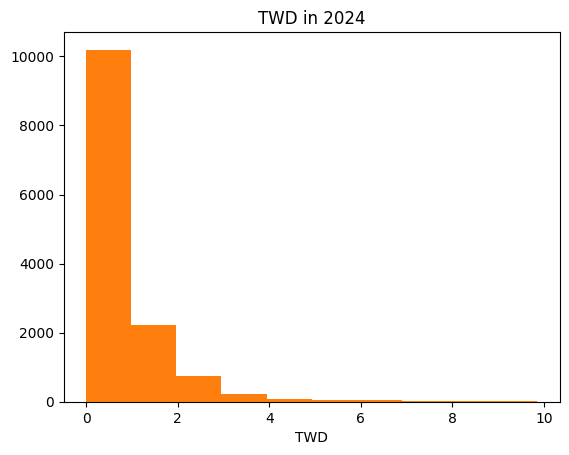

In [13]:
plt.hist(df_series_features_test['twd'], color = "tab:orange")
plt.title("TWD in 2024")
plt.xlabel("TWD")

Text(0.5, 0, 'TWD')

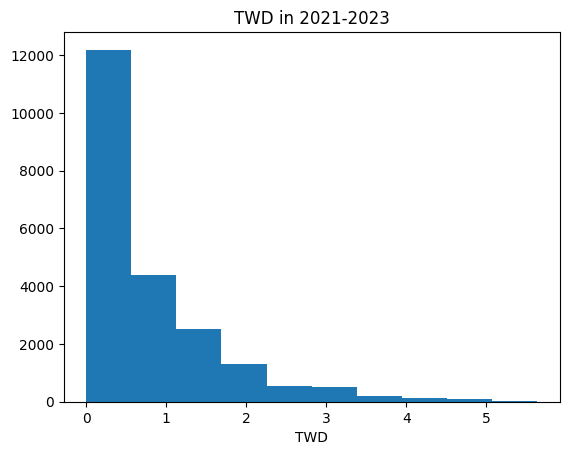

In [14]:
plt.hist(df_series_features['twd'])
plt.title("TWD in 2021-2023")
plt.xlabel("TWD")



split the data into training and test set
 - train and test set split by an even distribution of sites? 
 - easting and northing recommended
 - if autoregressive with lag =13
    - label: twd_t
    - input feature: [twd_t-12, twd_t-11, ...twd_t-1, at_t-1, lt_t-1]? 
    - can i use at_t as input feature?


Normalize certain colums: 

- pr	at	ws	dp	sr	lr	mch_elevation	site_longitude	site_latitude
- if twd was treated as feature should we then standardize it when model is autoregressive? 
- should we normalize it before or after splitting by windows? - i guess really no harm either way 

In [15]:
# Configure features
config = FeatureConfig()
lag_n =7 # use 7 and smaller model size 

# Autoregressive
# Split data
train_df_at, val_df_at, test_df_at = create_training_test_set_optimized(
    df_series_features_log2,
    feature_window_size=lag_n,
    autoregressive=True
)

train_df_at, val_df_at, test_df_at = standardize_dataset(
    train_df_at, val_df_at, test_df_at,
    config
)

# define final training, validation and test set

train_df_final_at, val_df_final_at, _ = create_training_test_set_optimized(
    df_series_features_log2,
    feature_window_size=lag_n,
    autoregressive=True,
    train_size = 0.85,
    val_size = 0.15
)

train_df_final_at, val_df_final_at, test_df_final_at = standardize_dataset(
    train_df_final_at, val_df_final_at, df_series_features_log2_test
)


# Create windows
train_X_ts_at, train_day_feat_X_at, train_static_X_ts_at,  train_y_at = get_dataset_LSTM(
    train_df_at,
    feature_window_size=lag_n,
    label_window_size = 1,
    autoregressive=True,
    shift = 1,
    config=config
)

val_X_ts_at, val_day_feat_X_at, val_static_X_ts_at, val_y_at = get_dataset_LSTM(
    val_df_at,
    feature_window_size=lag_n,
    label_window_size = 1,
    autoregressive=True,
    shift = 1,
    config=config
)

test_X_ts_at, test_day_feat_X_at, test_static_X_ts_at, test_y_at = get_dataset_LSTM(
    test_df_at,
    feature_window_size=lag_n,
    label_window_size = 1,
    autoregressive=True,
    shift = 1,
    config = config)


train_X_ts_final_at, train_day_feat_X_final_at, train_static_X_ts_final_at, train_y_final_at = get_dataset_LSTM(
    train_df_final_at,
    feature_window_size=lag_n,
    label_window_size = 1,
    autoregressive=True,
    shift = 1,
    config=config)

val_X_ts_final_at, val_day_feat_X_final_at, val_static_X_ts_final_at, val_y_final_at = get_dataset_LSTM(
    val_df_final_at,
    feature_window_size=lag_n,
    label_window_size = 1,
    autoregressive=True,
    shift = 1,  
    config = config)

test_X_ts_final_at, test_day_feat_X_final_at, test_static_X_ts_final_at, test_y_final_at = get_dataset_LSTM(
    test_df_final_at,
    feature_window_size=lag_n,
    label_window_size = 1,
    autoregressive=True,
    shift = 1,
    config = config)



2026-03-01 15:31:16.927252: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


### build LSTM
- LSTM 
- RNN
- and perhaps try elastic net to improve ridgeregression model performance, and try gaussian regressor

In [16]:

batch_size = 256
lag_n = 7

### Autoregressive
- reduce hidden space size to prevent overfitting

In [17]:
# building datasets
batch_size = batch_size

train_ds_at = tf.data.Dataset.from_tensor_slices((
    (train_X_ts_at, train_day_feat_X_at, train_static_X_ts_at),
    train_y_at,
))
train_ds_at = (
    train_ds_at
    .shuffle(buffer_size=train_X_ts_at.shape[0])
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds_at = tf.data.Dataset.from_tensor_slices((
    (val_X_ts_at, val_day_feat_X_at, val_static_X_ts_at),
    val_y_at,
))
val_ds_at = (
    val_ds_at
    .batch(batch_size)
        
) 

test_ds_at = tf.data.Dataset.from_tensor_slices((
    (test_X_ts_at, test_day_feat_X_at, test_static_X_ts_at),
    test_y_at,
))
test_ds_at = (
    test_ds_at.batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

# create dataset for final training and evaluation

train_ds_final_at = tf.data.Dataset.from_tensor_slices((
    (train_X_ts_final_at, train_day_feat_X_final_at, train_static_X_ts_final_at), 
    train_y_final_at 
))
train_ds_final_at = (
    train_ds_final_at.shuffle(buffer_size=train_X_ts_final_at.shape[0])
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds_final_at = tf.data.Dataset.from_tensor_slices((
    (val_X_ts_final_at, val_day_feat_X_final_at, val_static_X_ts_final_at), 
    val_y_final_at
)) 

val_ds_final_at = (
    val_ds_final_at.batch(batch_size)
    .prefetch(tf.data.AUTOTUNE))


test_ds_final_at = tf.data.Dataset.from_tensor_slices((
    (test_X_ts_final_at, test_day_feat_X_final_at, test_static_X_ts_final_at), 
    test_y_final_at
))
test_ds_final_at = (
    test_ds_final_at.batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)  

# create cross validate datasets tensorflow datasets

train_val_datasets_at = cross_validate_datasets(train_df_at, n_splits=4, feature_window_size=lag_n, config=config)

# build tf.data.Dataset for each fold
cv_train_val_ds_at = []
for train_cv_df_at, val_cv_df_at in train_val_datasets_at:
    
    train_cv_ds_at = build_ds_from_get_dataset_LSTM(
        train_cv_df_at ,
        feature_window_size=lag_n,
        config=config,
        autoregressive=True,
        shift=1,
        batch_size=batch_size,
    )
    val_cv_ds_at = build_ds_from_get_dataset_LSTM(
        val_cv_df_at,
        feature_window_size=lag_n,
        config=config,
        autoregressive=True,
        shift=1,
        batch_size=batch_size,
    )
    cv_train_val_ds_at.append((train_cv_ds_at, val_cv_ds_at))

    

In [18]:
# dynamic input
def build_autoregressive_model_lstm( train_X_ts_at, train_day_feat_X, train_static_X_ts, lag_n, hidden_unit = 16):
     # we don't actually need the input features but rather the shape information
    timesteps = lag_n
    n_features = train_X_ts_at.shape[2] # include TWD + other variables

    dyn_in = tf_keras.layers.Input(shape=(timesteps, n_features), name="past_dynamic")
    x_dyn = tf_keras.layers.LSTM(hidden_unit, return_sequences=False)(dyn_in)
    x_dyn = tf_keras.layers.Dense(hidden_unit, activation="relu")(x_dyn)

    # current day other features
    n_static = train_day_feat_X.shape[1]
    static_in = tf_keras.Input(shape=(n_static,), name="current_day_exog")
    x_static = tf_keras.layers.Dense(4, 
                                     activation="relu",
                                     kernel_regularizer=tf.keras.regularizers.l2(1e-3),
                                     )(static_in)

    # static input
    n_current = train_static_X_ts.shape[1]
    curr_in = tf_keras.Input(shape=(n_current,), name="static")
    x_curr = tf_keras.layers.Dense(4, 
                                   activation="relu",
                                   kernel_regularizer=tf.keras.regularizers.l2(1e-3),
                                   )(curr_in)


    combined = tf_keras.layers.Concatenate()([x_dyn, x_static, x_curr])
    x = tf_keras.layers.Dense(16, activation="relu")(combined)
    out = tf_keras.layers.Dense(1, activation = "linear")(x)


    model_at = tf_keras.Model(
    inputs=[dyn_in, static_in, curr_in],
    outputs=out,
    )

    model_at.compile(
        optimizer=tf_keras.optimizers.Adam(learning_rate=1e-4*5),
        loss="mae",
        metrics=[
        tf_keras.metrics.RootMeanSquaredError(name="rmse"),
        tf_keras.metrics.MeanAbsoluteError(name="mae"),
    ],
    )
    return model_at

In [19]:
# create two models with different hidden units 
num_epochs = 50
model_fold1 = build_autoregressive_model_lstm(train_X_ts_at, train_day_feat_X_at, train_static_X_ts_at, lag_n, hidden_unit = 16)
maes_cv_at, rmses_cv_at, rmses_cv_1d_at, r2s_cv_1d_at, r2s_cv_at, y_preds_cv_at, y_trues_cv_at, historys_cv_at = cross_validation_LSTM(
    model_fold1,
    cv_train_val_ds_at,
    train_val_datasets_at,
    lag_n,
    config,
    batch_size,
    num_epochs = num_epochs,
    if_log = True
)

model_fold2 = build_autoregressive_model_lstm(train_X_ts_at, train_day_feat_X_at, train_static_X_ts_at , lag_n, hidden_unit = 32)
maes_cv_at2, rmses_cv_at2, rmses_cv_1d_at2, r2s_cv_1d_at2, r2s_cv_at2, y_preds_cv_at2, y_trues_cv_at2, historys_cv_at2  = cross_validation_LSTM(
    model_fold2,
    cv_train_val_ds_at,
    train_val_datasets_at,
    lag_n,
    config,
    batch_size,
    num_epochs = num_epochs,
    if_log = True
)


Training fold 1/4
Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.5838 - mae: 0.5723 - rmse: 0.7667 - val_loss: 0.5543 - val_mae: 0.5429 - val_rmse: 0.7336
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5424 - mae: 0.5310 - rmse: 0.7153 - val_loss: 0.5563 - val_mae: 0.5449 - val_rmse: 0.7364
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5018 - mae: 0.4904 - rmse: 0.6622 - val_loss: 0.5597 - val_mae: 0.5484 - val_rmse: 0.7408
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4640 - mae: 0.4527 - rmse: 0.6098 - val_loss: 0.5652 - val_mae: 0.5539 - val_rmse: 0.7474
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4315 - mae: 0.4202 - rmse: 0.5622 - val_loss: 0.5716 - val_mae: 0.5604 - val_rmse: 0.7547
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4039 - mae: 0.3927 - rmse: 0.5212 - val_loss: 0.5767 - val_mae: 0.5655 - val_rmse: 0.7597
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3812 - mae: 0.3

2026-02-28 16:34:54.299327: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Training fold 2/4
Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5451 - mae: 0.5337 - rmse: 0.7196 - val_loss: 0.5825 - val_mae: 0.5711 - val_rmse: 0.7351
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4982 - mae: 0.4869 - rmse: 0.6556 - val_loss: 0.5383 - val_mae: 0.5270 - val_rmse: 0.6538
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4631 - mae: 0.4519 - rmse: 0.6064 - val_loss: 0.5129 - val_mae: 0.5017 - val_rmse: 0.6077
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4380 - mae: 0.4269 - rmse: 0.5714 - val_loss: 0.4960 - val_mae: 0.4850 - val_rmse: 0.5815
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4178 - mae: 0.4068 - rmse: 0.5432 - val_loss: 0.4788 - val_mae: 0.4679 - val_rmse: 0.5605
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3991 - mae: 0.3881 - rmse: 0.5180 - val_loss: 0.4582 - val_mae: 0.4473 - val_rmse: 0.5385
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3805 - mae: 0.3697 - r

2026-02-28 16:35:22.198481: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Training fold 3/4
Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.5602 - mae: 0.5488 - rmse: 0.7366 - val_loss: 0.4632 - val_mae: 0.4519 - val_rmse: 0.5892
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4817 - mae: 0.4705 - rmse: 0.6179 - val_loss: 0.4169 - val_mae: 0.4057 - val_rmse: 0.5230
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4266 - mae: 0.4156 - rmse: 0.5415 - val_loss: 0.3754 - val_mae: 0.3644 - val_rmse: 0.4697
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3819 - mae: 0.3709 - rmse: 0.4852 - val_loss: 0.3374 - val_mae: 0.3266 - val_rmse: 0.4194
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3391 - mae: 0.3283 - rmse: 0.4301 - val_loss: 0.2920 - val_mae: 0.2813 - val_rmse: 0.3574
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2929 - mae: 0.2823 - rmse: 0.3679 - val_loss: 0.2540 - val_mae: 0.2435 - val_rmse: 0.3155
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2587 - mae: 0.2483 - 

2026-02-28 16:36:24.920849: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Training fold 1/4
Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.5996 - mae: 0.5889 - rmse: 0.7667 - val_loss: 0.5351 - val_mae: 0.5244 - val_rmse: 0.6529
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5276 - mae: 0.5170 - rmse: 0.6763 - val_loss: 0.5128 - val_mae: 0.5021 - val_rmse: 0.6245
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4715 - mae: 0.4609 - rmse: 0.6000 - val_loss: 0.4943 - val_mae: 0.4838 - val_rmse: 0.6048
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4236 - mae: 0.4131 - rmse: 0.5317 - val_loss: 0.4787 - val_mae: 0.4682 - val_rmse: 0.5913
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3806 - mae: 0.3701 - rmse: 0.4703 - val_loss: 0.4623 - val_mae: 0.4518 - val_rmse: 0.5772
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3412 - mae: 0.3307 - rmse: 0.4178 - val_loss: 0.4428 - val_mae: 0.4323 - val_rmse: 0.5577
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3050 - mae: 0.29

2026-02-28 16:38:38.097792: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [20]:
rmses_cv_at2, rmses_cv_1d_at2, r2s_cv_1d_at2, r2s_cv_at2
rmses_cv_at, rmses_cv_1d_at, r2s_cv_1d_at, r2s_cv_at

([0.8782457133134797,
  0.6689547846174962,
  0.4498070407208811,
  0.6697155560491739],
 [0.642781674861908,
  0.42969369888305664,
  0.2031044065952301,
  0.2912363111972809],
 [0.22411274909973145,
  0.7669095396995544,
  0.9168605208396912,
  0.8980536460876465],
 [-0.42134058962079024,
  0.45030348745572313,
  0.5348010034136987,
  0.4547098460163982])

[Text(1, 0, 'hidden size =16'), Text(2, 0, 'hidden size =32')]

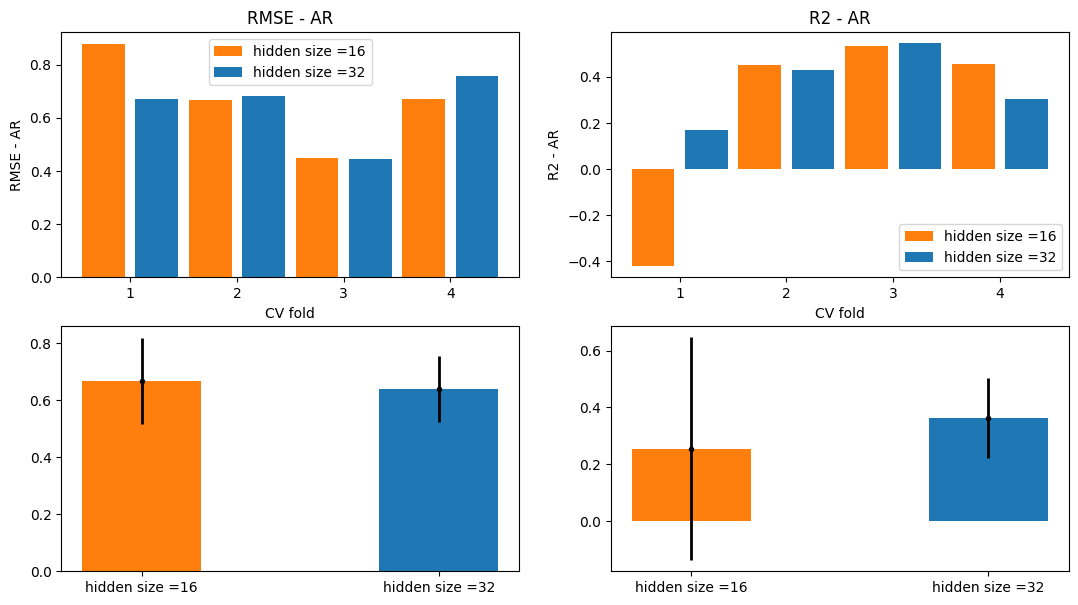

In [21]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(13, 7))

ax1.bar(np.arange(0.75,4.75, 1), rmses_cv_at, color='tab:orange', width = 0.4)
ax1.bar(np.arange(1.25,5.25,1),rmses_cv_at2, color = "tab:blue", width = 0.4)

ax1.set_xticks(range(1,5))
ax1.legend(['hidden size =16', 'hidden size =32'])
ax1.set_ylabel('RMSE - AR')
ax1.set_xlabel("CV fold")
ax1.set_title("RMSE - AR")
# rmses_cv_at


ax2.bar(np.arange(0.75, 4.75, 1), r2s_cv_at, color='tab:orange', width = 0.4)
ax2.bar(np.arange(1.25,5.25,1),r2s_cv_at2, color = "tab:blue", width = 0.4)
ax2.set_xticks(range(1,5))
ax2.legend(['hidden size =16', 'hidden size =32'])
ax2.set_ylabel('R2 - AR')
ax2.set_xlabel("CV fold")
ax2.set_title("R2 - AR")   


ax3.bar([1,2],  [np.mean(rmses_cv_at), np.mean(rmses_cv_at2)],
       color=['tab:orange', 'tab:blue'], width = 0.4)
ax3.errorbar(x = [1,2], y = [np.mean(rmses_cv_at), np.mean(rmses_cv_at2)], 
             yerr=[np.std(rmses_cv_at), np.std(rmses_cv_at2)],
             fmt='.', color='Black', elinewidth=2,capthick=10,errorevery=1)
ax3.set_xticks([1,2])
ax3.set_xticklabels(['hidden size =16', 'hidden size =32'])


ax4.bar([1,2],  [np.mean(r2s_cv_at), np.mean(r2s_cv_at2)],
       color=['tab:orange', 'tab:blue'], width = 0.4)
ax4.errorbar(x = [1,2], y = [np.mean(r2s_cv_at), np.mean(r2s_cv_at2)], 
             yerr=[np.std(r2s_cv_at), np.std(r2s_cv_at2)],
             fmt='.', color='Black', elinewidth=2,capthick=10,errorevery=1)
ax4.set_xticks([1,2])
ax4.set_xticklabels(['hidden size =16', 'hidden size =32'])
             

- performance appears more stable when hidden space dimension is 32 

In [19]:
hidden_unit_size = 32

In [20]:
model_at = build_autoregressive_model_lstm(train_X_ts_at, train_day_feat_X_at, train_static_X_ts_at, lag_n, hidden_unit = hidden_unit_size)
history_at = model_at.fit(
    train_ds_at,
    epochs=60,
    validation_data=val_ds_at,
)



Epoch 1/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.4112 - mae: 0.4004 - rmse: 0.5510 - val_loss: 0.2572 - val_mae: 0.2465 - val_rmse: 0.3242
Epoch 2/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2199 - mae: 0.2095 - rmse: 0.2974 - val_loss: 0.1810 - val_mae: 0.1707 - val_rmse: 0.2418
Epoch 3/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1822 - mae: 0.1722 - rmse: 0.2527 - val_loss: 0.1590 - val_mae: 0.1492 - val_rmse: 0.2154
Epoch 4/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1664 - mae: 0.1569 - rmse: 0.2348 - val_loss: 0.1466 - val_mae: 0.1373 - val_rmse: 0.2015
Epoch 5/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1541 - mae: 0.1449 - rmse: 0.2211 - val_loss: 0.1385 - val_mae: 0.1296 - val_rmse: 0.1908
Epoch 6/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1441 - mae: 0.1353 - rmse: 0.2098 - val_loss: 0.1291 - val_mae: 0.1206 - val_rmse: 0.1828
Epoch 7/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1359 - mae: 0.1275 - rmse: 0.2016 - val

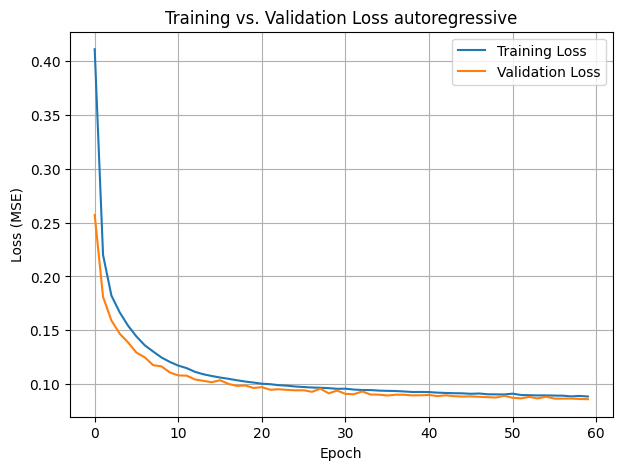

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
rmse: 0.189640, r2: 0.941292 


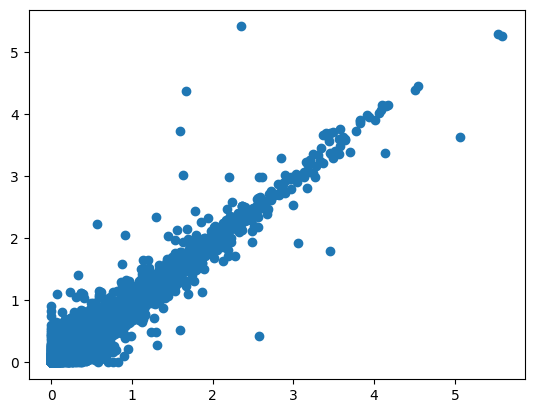

In [21]:


# Extract loss values
train_loss_at= history_at.history["loss"]
val_loss_at = history_at.history["val_loss"]

# Plot
plt.figure(figsize=(7, 5))
plt.plot(train_loss_at, label="Training Loss")
plt.plot(val_loss_at, label="Validation Loss")
plt.title("Training vs. Validation Loss autoregressive")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()




y_pred_val_1day_at= model_at.predict(val_ds_at)# show first few predictions

rmse_1day_at = root_mean_squared_error(clip_and_inverse_log2_transform(y_pred_val_1day_at), clip_and_inverse_log2_transform(val_y_at))
r2_1day_at = r2_score(clip_and_inverse_log2_transform(val_y_at), clip_and_inverse_log2_transform(y_pred_val_1day_at))
print(f'rmse: {rmse_1day_at:3f}, r2: {r2_1day_at:3f} ')
plt.scatter(clip_and_inverse_log2_transform(val_y_at), clip_and_inverse_log2_transform(y_pred_val_1day_at))

In [22]:
#sanity check on the newly built function with ridge regression, the prediction is the same from the other function
y_pred_val_at, y_val_at = compute_recursive_predictions_fast_LSTM(model_at, val_df_at, feature_window_size=lag_n,
label_window_size=1, shift=1, config=config, batch_size=128)

In [23]:
r2_at = r2_score(clip_and_inverse_log2_transform(y_val_at), clip_and_inverse_log2_transform(y_pred_val_at))
rmse_at = root_mean_squared_error(clip_and_inverse_log2_transform(y_val_at), clip_and_inverse_log2_transform(y_pred_val_at))

print(f"r2: {r2_at}\n rmse: {rmse_at}")

r2: 0.6333387125530281
 rmse: 0.47885314277651103


In [24]:
y_pred_test_at, y_test_at = compute_recursive_predictions_fast_LSTM(model_at, test_df_at, feature_window_size=lag_n,
label_window_size=1, shift=1, config=config, batch_size=128)

y_pred_test_1day = model_at.predict(test_ds_at)
y_test_1day = test_y_at.numpy().copy()

y_pred_test_at = clip_and_inverse_log2_transform(y_pred_test_at)
y_test_at = clip_and_inverse_log2_transform(y_test_at)

y_pred_test_1day = clip_and_inverse_log2_transform(y_pred_test_1day)
y_test_1day = clip_and_inverse_log2_transform(y_test_1day)


r2_at_test = r2_score(y_test_at, y_pred_test_at)
rmse_at_test = root_mean_squared_error(y_test_at, y_pred_test_at)

r2_test_1day = r2_score(y_test_1day, y_pred_test_1day)
rmse_test_1day = root_mean_squared_error(y_test_1day, y_pred_test_1day)
print(f"Test set performance - r2: {r2_at_test}\n rmse: {rmse_at_test}")
print(f"1-day prediction performance - r2: {r2_test_1day}\n rmse: {rmse_test_1day}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Test set performance - r2: 0.6742944269139004
 rmse: 0.677117488499549
1-day prediction performance - r2: 0.9474652409553528
 rmse: 0.2759398818016052


add cross-validation

In [35]:
# build a fresh model with identical architecture
model_ar = build_autoregressive_model_lstm(
    train_X_ts_at,
    train_day_feat_X_at,
    train_static_X_ts_at,
    lag_n=lag_n,
    hidden_unit=hidden_unit_size,
)

# copy weights from model_at (teacher-forced trained model)
model_ar.set_weights(model_at.get_weights())

# fine tune the model within CV

maes_cv_at_finetune, rmses_cv_at_finetune, rmses_cv_1d_at_finetune, r2s_cv_1d_at_finetune, \
r2s_cv_at_finetune, y_preds_cv_at_finetune, y_trues_cv_at_finetune, historys_cv_at_finetune = cross_validation_LSTM_FT(
    model_ar,
    train_val_datasets_at = train_val_datasets_at,
    lag_n = lag_n,
    config = config,
    num_epochs=50,
    batch_size = batch_size,
    if_log = True
)



Training fold 1/4
Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2075 - mae: 0.2059 - rmse: 0.2949 - val_loss: 0.1200 - val_mae: 0.1184 - val_rmse: 0.1815
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2004 - mae: 0.1987 - rmse: 0.2860 - val_loss: 0.1367 - val_mae: 0.1351 - val_rmse: 0.1980
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1995 - mae: 0.1978 - rmse: 0.2862 - val_loss: 0.1508 - val_mae: 0.1491 - val_rmse: 0.2119
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1972 - mae: 0.1955 - rmse: 0.2836 - val_loss: 0.1600 - val_mae: 0.1583 - val_rmse: 0.2214
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1953 - mae: 0.1937 - rmse: 0.2819 - val_loss: 0.1631 - val_mae: 0.1614 - val_rmse: 0.2249
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1939 - mae: 0.1923 - rmse: 0.2805 - val_loss: 0.1682 - val_mae: 0.1665 - val_rmse: 0.2314
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1927 - mae: 0.1910 - 

In [36]:
X_dyn_ar, X_day_ar, X_static_ar, y_ar = build_autoregressive_training_data_fast_LSTM(
    model=model_at,
    df=train_df_at,
    feature_window_size=lag_n,
    label_window_size=1,
    shift=1,
    config=config,
    batch_size=64,
)

ds_ar = tf.data.Dataset.from_tensor_slices(
    ((X_dyn_ar, X_day_ar, X_static_ar), y_ar)
).batch(64).prefetch(tf.data.AUTOTUNE)

In [37]:
# train final model on the full training set with AR-corrupted data
E2 = 50

# build a fresh model with identical architecture
model_ar = build_autoregressive_model_lstm(
    train_X_ts_at,
    train_day_feat_X_at,
    train_static_X_ts_at,
    lag_n=lag_n,
    hidden_unit=hidden_unit_size,
)

# copy weights from model_at (teacher-forced trained model)
model_ar.set_weights(model_at.get_weights())

# now fine-tune on AR-corrupted dataset
model_ar.fit(
    ds_ar,
    epochs=E2,
    validation_data=val_ds_at
)


Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.2241 - mae: 0.2225 - rmse: 0.3303 - val_loss: 0.1385 - val_mae: 0.1369 - val_rmse: 0.1958
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2216 - mae: 0.2200 - rmse: 0.3285 - val_loss: 0.1345 - val_mae: 0.1329 - val_rmse: 0.1947
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2192 - mae: 0.2177 - rmse: 0.3258 - val_loss: 0.1292 - val_mae: 0.1277 - val_rmse: 0.1881
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2177 - mae: 0.2161 - rmse: 0.3240 - val_loss: 0.1279 - val_mae: 0.1264 - val_rmse: 0.1869
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2168 - mae: 0.2153 - rmse: 0.3230 - val_loss: 0.1229 - val_mae: 0.1214 - val_rmse: 0.1812
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2158 - mae: 0.2143 - rmse: 0.3215 - val_loss: 0.1190 - val_mae: 0.1175 - val_rmse: 0.1756
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2147 - mae: 0.2133 - rmse:

In [38]:
#sanity check on the newly built function with ridge regression, the prediction is the same from the other function
y_pred_val_at_FT, y_val_at_FT = compute_recursive_predictions_fast_LSTM(model_ar, val_df_at, feature_window_size=lag_n,
label_window_size=1, shift=1, config=config, batch_size=64)

In [39]:
r2_FT = r2_score(clip_and_inverse_log2_transform(y_val_at_FT), clip_and_inverse_log2_transform(y_pred_val_at_FT))
rmse_FT = root_mean_squared_error(clip_and_inverse_log2_transform(y_val_at_FT), clip_and_inverse_log2_transform(y_pred_val_at_FT))

print(f"r2: {r2_FT}\n rmse: {rmse_FT}")

r2: 0.17894801427728546
 rmse: 0.7165642556440318


### scheduled sampling - train model

cross validation - implement cross validation

In [40]:
num_epochs = 45

# init model with same architecture
model_at_ar_cv = build_autoregressive_model_lstm(
    train_X_ts_at,
    train_day_feat_X_at,
    train_static_X_ts_at,
    lag_n=lag_n,
    hidden_unit=hidden_unit_size,
)
# copy weights from model_at (teacher-forced trained model)
model_at_ar_cv.set_weights(model_at.get_weights())

maes_cv_at_ar, rmses_cv_at_ar, rmses_cv_1d_at_ar, r2s_cv_1d_at_ar, \
r2s_cv_at_ar, y_preds_cv_at_ar, y_trues_cv_at_ar, historys_cv_at_ar = cross_validation_LSTM_AR(
    model_at_ar_cv,
    train_val_datasets_at = train_val_datasets_at,
    lag_n = lag_n,
    config = config,
    num_epochs=num_epochs,
    batch_size = batch_size,
    p_min = 0.1,
    warmup_epochs=3,
    frac_decay=0.9,
    slow_decay=True,
    if_log = True)




Training fold 1/4
Epoch 1/45 - loss: 0.0909 - rmse: 0.1530 - val_loss: 0.1260 - val_rmse: 0.1898 - p_tf: 1.000


2026-02-08 21:35:49.409894: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 2/45 - loss: 0.0888 - rmse: 0.1513 - val_loss: 0.1194 - val_rmse: 0.1825 - p_tf: 1.000
Epoch 3/45 - loss: 0.0880 - rmse: 0.1506 - val_loss: 0.1216 - val_rmse: 0.1842 - p_tf: 1.000
Epoch 4/45 - loss: 0.0927 - rmse: 0.1582 - val_loss: 0.1271 - val_rmse: 0.1902 - p_tf: 0.871
Epoch 5/45 - loss: 0.0918 - rmse: 0.1572 - val_loss: 0.1220 - val_rmse: 0.1846 - p_tf: 0.871
Epoch 6/45 - loss: 0.0914 - rmse: 0.1569 - val_loss: 0.1183 - val_rmse: 0.1809 - p_tf: 0.871
Epoch 7/45 - loss: 0.0904 - rmse: 0.1561 - val_loss: 0.1158 - val_rmse: 0.1781 - p_tf: 0.871
Epoch 8/45 - loss: 0.0898 - rmse: 0.1550 - val_loss: 0.1164 - val_rmse: 0.1791 - p_tf: 0.871
Epoch 9/45 - loss: 0.0961 - rmse: 0.1609 - val_loss: 0.1179 - val_rmse: 0.1808 - p_tf: 0.743


2026-02-08 21:37:38.239471: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 10/45 - loss: 0.0954 - rmse: 0.1602 - val_loss: 0.1151 - val_rmse: 0.1768 - p_tf: 0.743
Epoch 11/45 - loss: 0.0947 - rmse: 0.1585 - val_loss: 0.1238 - val_rmse: 0.1871 - p_tf: 0.743
Epoch 12/45 - loss: 0.0946 - rmse: 0.1589 - val_loss: 0.1114 - val_rmse: 0.1728 - p_tf: 0.743
Epoch 13/45 - loss: 0.0938 - rmse: 0.1579 - val_loss: 0.1195 - val_rmse: 0.1827 - p_tf: 0.743
Epoch 14/45 - loss: 0.1014 - rmse: 0.1678 - val_loss: 0.1196 - val_rmse: 0.1832 - p_tf: 0.614
Epoch 15/45 - loss: 0.1006 - rmse: 0.1676 - val_loss: 0.1205 - val_rmse: 0.1836 - p_tf: 0.614
Epoch 16/45 - loss: 0.1003 - rmse: 0.1673 - val_loss: 0.1177 - val_rmse: 0.1810 - p_tf: 0.614
Epoch 17/45 - loss: 0.1001 - rmse: 0.1664 - val_loss: 0.1224 - val_rmse: 0.1863 - p_tf: 0.614
Epoch 18/45 - loss: 0.1003 - rmse: 0.1668 - val_loss: 0.1265 - val_rmse: 0.1913 - p_tf: 0.614
Epoch 19/45 - loss: 0.1106 - rmse: 0.1811 - val_loss: 0.1192 - val_rmse: 0.1832 - p_tf: 0.486
Epoch 20/45 - loss: 0.1083 - rmse: 0.1779 - val_loss: 0.1204

...

Epoch 26/45 - loss: 0.1249 - rmse: 0.2008 - val_loss: 0.1175 - val_rmse: 0.1777 - p_tf: 0.357
Epoch 27/45 - loss: 0.1259 - rmse: 0.1936 - val_loss: 0.1206 - val_rmse: 0.1861 - p_tf: 0.357
Epoch 28/45 - loss: 0.1302 - rmse: 0.2082 - val_loss: 0.1498 - val_rmse: 0.2174 - p_tf: 0.357
Epoch 29/45 - loss: 0.1788 - rmse: 0.2623 - val_loss: 0.1230 - val_rmse: 0.1763 - p_tf: 0.229
Epoch 30/45 - loss: 0.2268 - rmse: 0.3318 - val_loss: 0.3119 - val_rmse: 0.4210 - p_tf: 0.229
Epoch 31/45 - loss: 0.2566 - rmse: 0.3752 - val_loss: 0.3085 - val_rmse: 0.4335 - p_tf: 0.229
Epoch 32/45 - loss: 0.2769 - rmse: 0.4050 - val_loss: 0.1659 - val_rmse: 0.2226 - p_tf: 0.229
Epoch 33/45 - loss: 0.2805 - rmse: 0.3974 - val_loss: 0.2881 - val_rmse: 0.4108 - p_tf: 0.229
Epoch 34/45 - loss: 0.3645 - rmse: 0.5138 - val_loss: 0.3025 - val_rmse: 0.4351 - p_tf: 0.100
Epoch 35/45 - loss: 0.2648 - rmse: 0.3750 - val_loss: 0.2374 - val_rmse: 0.3408 - p_tf: 0.100
Epoch 36/45 - loss: 0.3270 - rmse: 0.4453 - val_loss: 0.2795

2026-02-08 21:49:17.425223: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 13/45 - loss: 0.0985 - rmse: 0.1652 - val_loss: 0.1099 - val_rmse: 0.1984 - p_tf: 0.743
Epoch 14/45 - loss: 0.1053 - rmse: 0.1746 - val_loss: 0.1099 - val_rmse: 0.1986 - p_tf: 0.614
Epoch 15/45 - loss: 0.1043 - rmse: 0.1726 - val_loss: 0.1120 - val_rmse: 0.1998 - p_tf: 0.614
Epoch 16/45 - loss: 0.1052 - rmse: 0.1738 - val_loss: 0.1137 - val_rmse: 0.2008 - p_tf: 0.614
Epoch 17/45 - loss: 0.1040 - rmse: 0.1727 - val_loss: 0.1112 - val_rmse: 0.1986 - p_tf: 0.614
Epoch 18/45 - loss: 0.1042 - rmse: 0.1722 - val_loss: 0.1111 - val_rmse: 0.1986 - p_tf: 0.614
Epoch 19/45 - loss: 0.1143 - rmse: 0.1862 - val_loss: 0.1126 - val_rmse: 0.2002 - p_tf: 0.486
Epoch 20/45 - loss: 0.1129 - rmse: 0.1845 - val_loss: 0.1114 - val_rmse: 0.1982 - p_tf: 0.486
Epoch 21/45 - loss: 0.1162 - rmse: 0.1867 - val_loss: 0.1115 - val_rmse: 0.1995 - p_tf: 0.486
Epoch 22/45 - loss: 0.1140 - rmse: 0.1845 - val_loss: 0.1140 - val_rmse: 0.2005 - p_tf: 0.486
Epoch 23/45 - loss: 0.1125 - rmse: 0.1834 - val_loss: 0.1128

2026-02-08 22:06:52.352918: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 31/45 - loss: 0.2298 - rmse: 0.3336 - val_loss: 0.1301 - val_rmse: 0.1999 - p_tf: 0.229
Epoch 32/45 - loss: 0.2570 - rmse: 0.3655 - val_loss: 0.1144 - val_rmse: 0.1794 - p_tf: 0.229
Epoch 33/45 - loss: 0.2364 - rmse: 0.3468 - val_loss: 0.1230 - val_rmse: 0.1940 - p_tf: 0.229
Epoch 34/45 - loss: 0.2729 - rmse: 0.3882 - val_loss: 0.1491 - val_rmse: 0.2144 - p_tf: 0.100
Epoch 35/45 - loss: 0.3209 - rmse: 0.4480 - val_loss: 0.2340 - val_rmse: 0.3461 - p_tf: 0.100
Epoch 36/45 - loss: 0.4453 - rmse: 0.6222 - val_loss: 0.2784 - val_rmse: 0.4022 - p_tf: 0.100
Epoch 37/45 - loss: 0.3777 - rmse: 0.5250 - val_loss: 0.2285 - val_rmse: 0.2908 - p_tf: 0.100
Epoch 38/45 - loss: 0.3576 - rmse: 0.4792 - val_loss: 0.2659 - val_rmse: 0.3835 - p_tf: 0.100
Epoch 39/45 - loss: 0.3324 - rmse: 0.4656 - val_loss: 0.1838 - val_rmse: 0.2439 - p_tf: 0.100
Epoch 40/45 - loss: 0.3272 - rmse: 0.4428 - val_loss: 0.2561 - val_rmse: 0.3714 - p_tf: 0.100
Epoch 41/45 - loss: 0.3152 - rmse: 0.4500 - val_loss: 0.1757

- more epochs, decay slower, stepwise training 
- hidden size 16, shorter window

In [ ]:
# now do scheduled sampling training on the full training set
num_epochs = 120

history_ar_at = {
"loss": [],
"rmse": [],
"val_loss": [],
"val_rmse": [],
"p_tf": []
}


# init model with same architecture
model_at_ar = build_autoregressive_model_lstm(
    train_X_ts_at,
    train_day_feat_X_at,
    train_static_X_ts_at,
    lag_n=lag_n,
    hidden_unit=hidden_unit_size,
)
# copy weights from model_at (teacher-forced trained model)
model_at_ar.set_weights(model_at.get_weights())



for epoch in range(num_epochs):
        # train model with teacher forcing for the first epoch 
    p_tf = teacher_forcing_prob_stepwise(epoch, num_epochs,epoch_per_step=15, step_size=0.1, p0=1.0, p_min=0.1, warmup_epochs=3, frac_decay=0.9)
    history_ar_at["p_tf"].append(p_tf)

    # rebuild AR / scheduled-sampling training data
    X_dyn_ar_at, X_day_ar_at, X_static_ar_at, y_ar_at = build_autoregressive_training_data_fast_LSTM_scheduled(
        model_at_ar,
        train_df_at,
        feature_window_size=lag_n,
        label_window_size=1,
        shift=1,
        config=config,
        batch_size=batch_size,
        teacher_forcing_prob=p_tf,
    )

    train_ds_at_decay = (
        tf.data.Dataset.from_tensor_slices(((X_dyn_ar_at, X_day_ar_at, X_static_ar_at), y_ar_at))
        .shuffle(len(X_dyn_ar_at))
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )

    # one epoch of manual training
    epoch_loss = tf.keras.metrics.Mean()
    epoch_rmse = tf.keras.metrics.RootMeanSquaredError()

    for (x_dyn, x_day, x_stat), y in train_ds_at_decay:
        with tf.GradientTape() as tape:
            preds = model_at_ar([x_dyn, x_day, x_stat], training=True)
            loss = model_at_ar.compute_loss(x=None, y=y, y_pred=preds, sample_weight=None, training=True)

        grads = tape.gradient(loss, model_at_ar.trainable_variables)
        model_at_ar.optimizer.apply_gradients(zip(grads, model_at_ar.trainable_variables))      
        epoch_loss.update_state(loss)
        epoch_rmse.update_state(y, preds)

    # validation
    val_loss_metric = tf.keras.metrics.Mean()
    val_rmse_metric = tf.keras.metrics.RootMeanSquaredError()
    for (x_dyn_v, x_day_v, x_stat_v), y_v in val_ds_at:
        preds_v = model_at_ar([x_dyn_v, x_day_v, x_stat_v], training=False)
        v_loss = model_at_ar.compute_loss(x=None, y=y_v, y_pred=preds_v, sample_weight=None, training=False)
        val_loss_metric.update_state(v_loss)
        val_rmse_metric.update_state(y_v, preds_v)

    history_ar_at["loss"].append(epoch_loss.result().numpy())
    history_ar_at["rmse"].append(epoch_rmse.result().numpy())
    history_ar_at["val_loss"].append(val_loss_metric.result().numpy())
    history_ar_at["val_rmse"].append(val_rmse_metric.result().numpy())
    history_ar_at["p_tf"].append(p_tf)

    print(
        f"Epoch {epoch+1}/{num_epochs} - "
        f"loss: {history_ar_at['loss'][-1]:.4f} - rmse: {history_ar_at['rmse'][-1]:.4f} - "
        f"val_loss: {history_ar_at['val_loss'][-1]:.4f} - val_rmse: {history_ar_at['val_rmse'][-1]:.4f} - "
        f"p_tf: {p_tf:.3f}"
    )

Epoch 1/120 - loss: 0.0849 - rmse: 0.1572 - val_loss: 0.0823 - val_rmse: 0.1426 - p_tf: 1.000
Epoch 2/120 - loss: 0.0848 - rmse: 0.1566 - val_loss: 0.0837 - val_rmse: 0.1453 - p_tf: 1.000
Epoch 3/120 - loss: 0.0845 - rmse: 0.1567 - val_loss: 0.0828 - val_rmse: 0.1430 - p_tf: 1.000
Epoch 4/120 - loss: 0.0898 - rmse: 0.1640 - val_loss: 0.0843 - val_rmse: 0.1435 - p_tf: 0.871
Epoch 5/120 - loss: 0.0907 - rmse: 0.1675 - val_loss: 0.0843 - val_rmse: 0.1442 - p_tf: 0.871
Epoch 6/120 - loss: 0.0909 - rmse: 0.1662 - val_loss: 0.0830 - val_rmse: 0.1446 - p_tf: 0.871
Epoch 7/120 - loss: 0.0901 - rmse: 0.1654 - val_loss: 0.0836 - val_rmse: 0.1447 - p_tf: 0.871
Epoch 8/120 - loss: 0.0898 - rmse: 0.1632 - val_loss: 0.0835 - val_rmse: 0.1432 - p_tf: 0.871
Epoch 9/120 - loss: 0.0896 - rmse: 0.1649 - val_loss: 0.0856 - val_rmse: 0.1446 - p_tf: 0.871
Epoch 10/120 - loss: 0.0894 - rmse: 0.1634 - val_loss: 0.0829 - val_rmse: 0.1433 - p_tf: 0.871
Epoch 11/120 - loss: 0.0901 - rmse: 0.1644 - val_loss: 0.08

2026-01-01 14:40:01.589515: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 68/120 - loss: 0.1217 - rmse: 0.2034 - val_loss: 0.0932 - val_rmse: 0.1491 - p_tf: 0.357
Epoch 69/120 - loss: 0.1209 - rmse: 0.2039 - val_loss: 0.0931 - val_rmse: 0.1462 - p_tf: 0.357
Epoch 70/120 - loss: 0.1193 - rmse: 0.1990 - val_loss: 0.0934 - val_rmse: 0.1508 - p_tf: 0.357
Epoch 71/120 - loss: 0.1215 - rmse: 0.2035 - val_loss: 0.0927 - val_rmse: 0.1458 - p_tf: 0.357
Epoch 72/120 - loss: 0.1206 - rmse: 0.1987 - val_loss: 0.0991 - val_rmse: 0.1555 - p_tf: 0.357
Epoch 73/120 - loss: 0.1253 - rmse: 0.2067 - val_loss: 0.0960 - val_rmse: 0.1501 - p_tf: 0.357
Epoch 74/120 - loss: 0.1241 - rmse: 0.2033 - val_loss: 0.0953 - val_rmse: 0.1512 - p_tf: 0.357
Epoch 75/120 - loss: 0.1194 - rmse: 0.1987 - val_loss: 0.0941 - val_rmse: 0.1496 - p_tf: 0.357
Epoch 76/120 - loss: 0.1191 - rmse: 0.1988 - val_loss: 0.0992 - val_rmse: 0.1541 - p_tf: 0.357
Epoch 77/120 - loss: 0.1214 - rmse: 0.2010 - val_loss: 0.0966 - val_rmse: 0.1543 - p_tf: 0.357
Epoch 78/120 - loss: 0.1237 - rmse: 0.2073 - val_l

maybe adjust loss function?

In [ ]:
# save training history
train_his_path = f"/cluster/home/taoj/work_dir/eth-capstone/tree-water-deficit/data/derived/training_history/history_ar_at_LSTM_scheduled_sampling_log.npy"
np.save(train_his_path, history_ar_at)

In [56]:
#sanity check on the newly built function with ridge regression, the prediction is the same from the other function
y_pred_val_at_ar, y_val_at_ar= compute_recursive_predictions_fast_LSTM(model_at_ar, val_df_at, feature_window_size=lag_n,
label_window_size=1, shift=1, config=config, batch_size=64)
r2_at_ar = r2_score(clip_and_inverse_log2_transform(y_val_at_ar),clip_and_inverse_log2_transform(y_pred_val_at_ar))
rmse_at_ar = root_mean_squared_error(clip_and_inverse_log2_transform(y_val_at_ar), clip_and_inverse_log2_transform(y_pred_val_at_ar))

print(f"r2: {r2_at_ar}\n rmse: {rmse_at_ar}")

r2: -1.033223056711222
 rmse: 1.1276188457191507


In [41]:
# plot performance together

df_model_performance = pd.DataFrame({
    "model" :['teacher_forcing (hidden=16)'] *4 + ['teacher_forcing (hidden=32)'] *4 + ['fine_tuned (hidden=32)'] *4 + ['scheduled_sampling (hidden=32)'] *4,    
    "cv_fold"  : [i for i in range(1, len(maes_cv_at_ar) + 1)] *4,
    "mae": maes_cv_at + maes_cv_at2 + maes_cv_at_finetune + maes_cv_at_ar,
    "rmse_recursive": rmses_cv_at + rmses_cv_at2 + rmses_cv_at_finetune + rmses_cv_at_ar,
    "rmse_1day": rmses_cv_1d_at + rmses_cv_1d_at2 + rmses_cv_1d_at_finetune + rmses_cv_1d_at_ar,
    "r2_1day" : r2s_cv_1d_at + r2s_cv_1d_at2 + r2s_cv_1d_at_finetune + r2s_cv_1d_at_ar,
    "r2_recursive": r2s_cv_at + r2s_cv_at2 + r2s_cv_at_finetune + r2s_cv_at_ar,
    "lag_n" : [lag_n]*16
}
)
df_model_performance.to_csv(os.path.join(model_performance_path, f"model_performance_LSTM_7_day_FT_SS_log_lag{lag_n}.csv"), index=False)

df_model_p_long = df_model_performance.melt(id_vars=["model", "cv_fold"], 
                                        value_vars=["mae", "rmse_recursive", "rmse_1day", "r2_1day", "r2_recursive"],
                                        var_name="metric",
                                        value_name="value"
                                        )

In [68]:
df_model_p_long.loc[df_model_p_long.metric == "r2_recursive",]

,model,cv_fold,metric,value
64,teacher_forcing (hidden=16),1,r2_recursive,-0.521440
65,teacher_forcing (hidden=16),2,r2_recursive,0.397385
66,teacher_forcing (hidden=16),3,r2_recursive,0.524935
67,teacher_forcing (hidden=16),4,r2_recursive,0.549017
68,teacher_forcing (hidden=32),1,r2_recursive,0.030626
69,teacher_forcing (hidden=32),2,r2_recursive,0.462569
70,teacher_forcing (hidden=32),3,r2_recursive,0.596747
71,teacher_forcing (hidden=32),4,r2_recursive,0.461816
72,fine_tuned (hidden=32),1,r2_recursive,-0.291047
73,fine_tuned (hidden=32),2,r2_recursive,0.439742


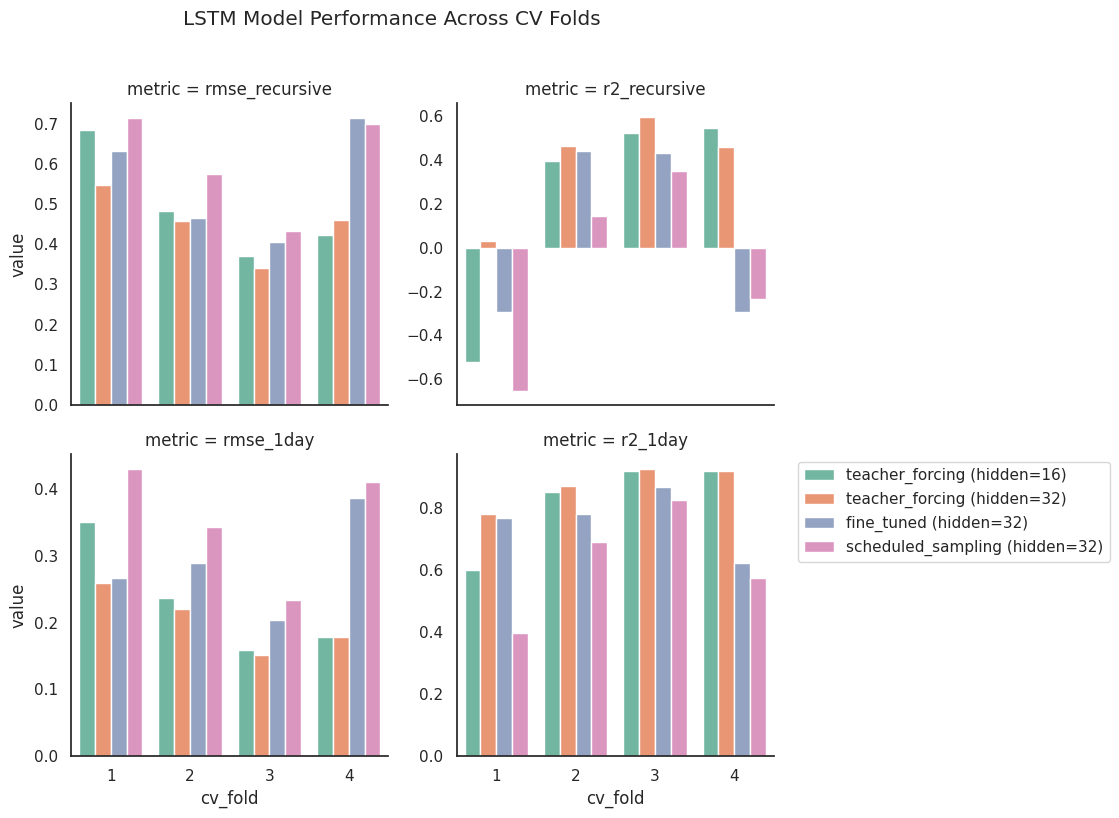

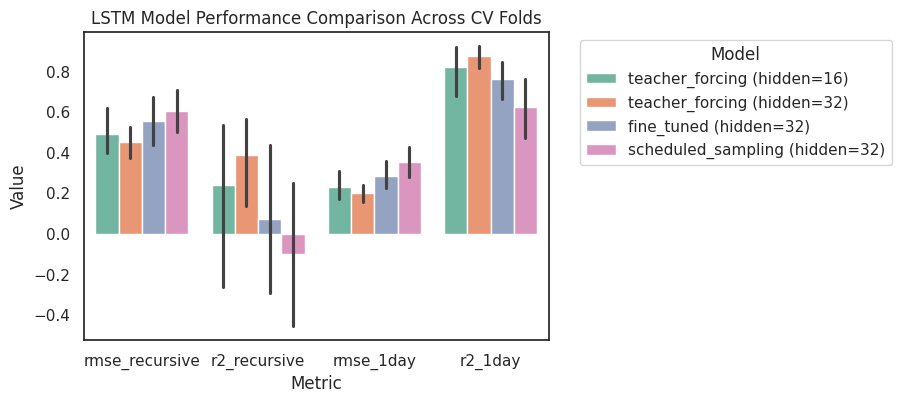

In [ ]:
sns.set(style="white", font_scale=1,
        rc={"figure.figsize": (6, 4)})

metrics_plot = ['rmse_recursive', 'r2_recursive', 'rmse_1day', 'r2_1day']
df_p_plot = df_model_p_long.loc[df_model_p_long['metric'].isin(
metrics_plot
)]  
g = sns.FacetGrid(df_p_plot, col="metric", col_wrap = 2,
              col_order = metrics_plot,
              height=4, sharey=False).map_dataframe(
    sns.barplot,
    x="cv_fold",
    y="value",
    hue = 'model',
    palette = "Set2",
    legend = True,
)

g.figure.suptitle("LSTM Model Performance Across CV Folds", y=1.02)


plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

sns.barplot(df_p_plot, x="metric", y="value", hue="model", palette="Set2",
            order = metrics_plot)
plt.title("LSTM Model Performance Comparison Across CV Folds")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1))
plt.show()


/scratch/tmp.53027694.taoj/ipykernel_2829603/3687270685.py:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax1.plot(x_range, x_range, 'k--', lw=2, color="tab:orange")
/scratch/tmp.53027694.taoj/ipykernel_2829603/3687270685.py:20: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax1.plot(x_range, [i+rmse_at for i in x_range], 'k--', lw=2, color="gold")
/scratch/tmp.53027694.taoj/ipykernel_2829603/3687270685.py:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax1.plot(x_range, [i-rmse_at for i in x_range], 'k--', lw=2, color="gold")
/scratch/tmp.53027694.taoj/ipykernel_2829603/3687270685.py:34: UserWarning: color is redundantly defined by the 'color' k

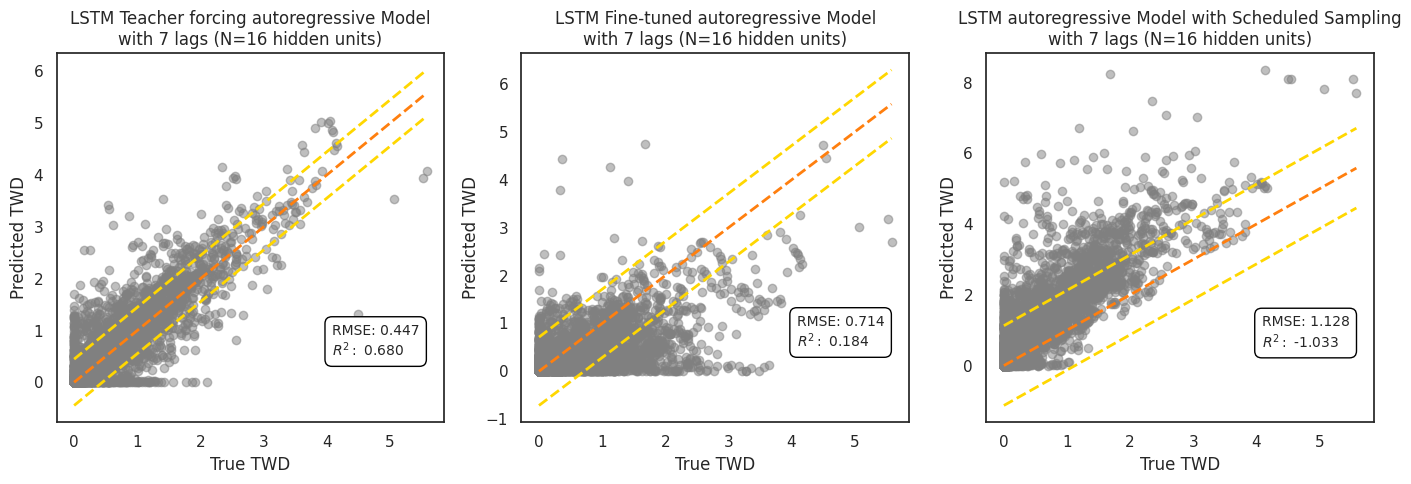

In [70]:
# Create figure with 3 subplots showing model final performance

def ensure_numpy(x):
    if isinstance(x, tf.Tensor):
        return x.numpy()
    return np.asarray(x)
y_val_at = clip_and_inverse_log2_transform(ensure_numpy(y_val_at).reshape(-1))
y_pred_val_at = clip_and_inverse_log2_transform(ensure_numpy(y_pred_val_at).reshape(-1))
# val_y = ensure_numpy(val_y)

fig, ((ax1, ax2, ax3)) = plt.subplots(1, 3, figsize=(14, 5))


# First subplot - Autoregressive Model Predictions hidden 32
ax1.scatter(x=y_val_at, y=y_pred_val_at, color="grey", alpha=0.5)
ax1.set_xlabel("True TWD")
ax1.set_ylabel("Predicted TWD")
x_range = [y_val_at.min(), y_val_at.max()]
ax1.plot(x_range, x_range, 'k--', lw=2, color="tab:orange")
ax1.plot(x_range, [i+rmse_at for i in x_range], 'k--', lw=2, color="gold")
ax1.plot(x_range, [i-rmse_at for i in x_range], 'k--', lw=2, color="gold")
ax1.set_title(f"LSTM Teacher forcing autoregressive Model\nwith {lag_n} lags (N=16 hidden units)")
ax1.text(y_val_at.max()-1.5,y_pred_val_at.min()+0.5, 
         f"RMSE: {rmse_at:.3f}\n$R^2:$ {r2_at:.3f}", 
         fontsize=10, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))



# plot fine-tuned 
ax2.scatter(x =  clip_and_inverse_log2_transform(ensure_numpy(y_val_at_FT).reshape(-1)), y = clip_and_inverse_log2_transform(ensure_numpy(y_pred_val_at_FT).reshape(-1)), color="grey", alpha=0.5)
ax2.set_xlabel("True TWD")
ax2.set_ylabel("Predicted TWD")
x_range = [clip_and_inverse_log2_transform(ensure_numpy(y_val_at_FT).reshape(-1)).min(), clip_and_inverse_log2_transform(ensure_numpy(y_val_at_FT).reshape(-1)).max()]
ax2.plot(x_range, x_range, 'k--', lw=2, color="tab:orange")
ax2.plot(x_range, [i+rmse_FT for i in x_range], 'k--', lw=2, color="gold")
ax2.plot(x_range, [i-rmse_FT for i in x_range], 'k--', lw=2, color="gold")
ax2.set_title(f"LSTM Fine-tuned autoregressive Model\nwith {lag_n} lags (N=16 hidden units)")
ax2.text(clip_and_inverse_log2_transform(ensure_numpy(y_val_at_FT).reshape(-1)).max()-1.5,clip_and_inverse_log2_transform(ensure_numpy(y_pred_val_at_FT).reshape(-1)).min()+0.5, 
         f"RMSE: {rmse_FT:.3f}\n$R^2:$ {r2_FT:.3f}", 
         fontsize=10, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))   


# plot scheduled sampling 
ax3.scatter(x = clip_and_inverse_log2_transform(ensure_numpy(y_val_at_ar).reshape(-1)), y = clip_and_inverse_log2_transform(ensure_numpy(y_pred_val_at_ar).reshape(-1)), color="grey", alpha=0.5)
ax3.set_xlabel("True TWD")
ax3.set_ylabel("Predicted TWD")
x_range = [clip_and_inverse_log2_transform(ensure_numpy(y_val_at_ar).reshape(-1)).min(), clip_and_inverse_log2_transform(ensure_numpy(y_val_at_ar).reshape(-1)).max()]
ax3.plot(x_range, x_range, 'k--', lw=2, color="tab:orange")
ax3.plot(x_range, [i+rmse_at_ar for i in x_range], 'k--', lw=2, color="gold")
ax3.plot(x_range, [i-rmse_at_ar for i in x_range], 'k--', lw=2, color="gold")
ax3.set_title(f"LSTM autoregressive Model with Scheduled Sampling\nwith {lag_n} lags (N=16 hidden units)")
ax3.text(clip_and_inverse_log2_transform(ensure_numpy(y_val_at_ar).reshape(-1)).max()-1.5,clip_and_inverse_log2_transform(ensure_numpy(y_pred_val_at_ar).reshape(-1)).min()+0.5, 
         f"RMSE: {rmse_at_ar:.3f}\n$R^2:$ {r2_at_ar:.3f}", 
         fontsize=10, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))  

plt.tight_layout()
plt.show()



# Train model on final training set and test performance

In [25]:
hidden_unit_size = 32

In [26]:
model_at_final = build_autoregressive_model_lstm(train_X_ts_at, train_day_feat_X_at, train_static_X_ts_at, lag_n, hidden_unit = hidden_unit_size)
history_at_final = model_at_final.fit(
    train_ds_final_at,
    epochs=70,
    validation_data=val_ds_final_at,
)


Epoch 1/70
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.4035 - mae: 0.3925 - rmse: 0.5457 - val_loss: 0.2864 - val_mae: 0.2758 - val_rmse: 0.3612
Epoch 2/70
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1956 - mae: 0.1852 - rmse: 0.2633 - val_loss: 0.2073 - val_mae: 0.1971 - val_rmse: 0.2770
Epoch 3/70
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1651 - mae: 0.1552 - rmse: 0.2304 - val_loss: 0.1794 - val_mae: 0.1697 - val_rmse: 0.2471
Epoch 4/70
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1509 - mae: 0.1413 - rmse: 0.2146 - val_loss: 0.1621 - val_mae: 0.1527 - val_rmse: 0.2289
Epoch 5/70
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1401 - mae: 0.1309 - rmse: 0.2029 - val_loss: 0.1526 - val_mae: 0.1437 - val_rmse: 0.2168
Epoch 6/70
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1311 - mae: 0.1223 - rmse: 0.1939 - val_loss: 0.1437 - val_mae: 0.1351 - val_rmse: 0.2067
Epoch 7/70
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1244 - mae: 0.1160 - rmse: 0.1873 - val

In [27]:
# 1‑day predictions without tf.data
# y_pred_1day_final = model_at_final.predict(
#     test_ds_final_at
# )
# True values are just the original array
y_true_1day_final = []
y_pred_1day_final = []
for batch in test_ds_final_at:
    input, y_batch = batch
    y_pred_batch = model_at_final.predict(input)
    y_true_1day_final.append(y_batch.numpy())
    y_pred_1day_final.append(y_pred_batch)
y_true_1day_final = np.concatenate(y_true_1day_final, axis=0)
y_pred_1day_final = np.concatenate(y_pred_1day_final, axis=0)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━

2026-03-01 15:33:04.701417: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [28]:
# Recursive predictions remain the same
# y_true_1day_final = test_y_final_at.numpy().copy()
test_y_pred_final_at, test_y_final_at_recursive = utils.compute_recursive_predictions_fast_LSTM(
    model_at_final, test_df_final_at,
    feature_window_size=lag_n, label_window_size=1,
    shift=1, config=config, batch_size=128
)

# Undo the log transform
y_pred_1day_final = clip_and_inverse_log2_transform(y_pred_1day_final)
y_true_1day_final = clip_and_inverse_log2_transform(y_true_1day_final)
test_y_pred_final_at = clip_and_inverse_log2_transform(test_y_pred_final_at)
test_y_final_at_recursive = clip_and_inverse_log2_transform(test_y_final_at_recursive)

In [29]:
rmse_test_at_final = root_mean_squared_error(test_y_final_at_recursive, test_y_pred_final_at)
r2_test_at_final = r2_score(test_y_final_at_recursive, test_y_pred_final_at)

rmse_1day_final = root_mean_squared_error(y_true_1day_final, y_pred_1day_final)
r2_1day_final = r2_score(y_true_1day_final, y_pred_1day_final)

print(f"Final Test set performance - Recursive prediction - RMSE: {rmse_test_at_final:.3f}, R2: {r2_test_at_final:.3f}")
print(f"Final Test set performance - 1-day prediction - RMSE: {rmse_1day_final:.3f}, R2: {r2_1day_final:.3f}")

Final Test set performance - Recursive prediction - RMSE: 0.820, R2: 0.333
Final Test set performance - 1-day prediction - RMSE: 0.872, R2: 0.240


In [30]:
df_final_test_performance = pd.DataFrame({
    "prediction": np.concatenate([y_pred_1day_final.flatten(), y_pred_test_1day.flatten(), test_y_pred_final_at, y_pred_test_at], axis = 0),
    "actual": np.concatenate([y_true_1day_final.flatten(), y_test_1day.flatten(), test_y_final_at_recursive, y_test_at], axis = 0),
    "test_set": ["final_test"] * (len(y_pred_1day_final.flatten())) + ["test"] * len(y_pred_test_1day.flatten()) + ["final_test"] * len(test_y_pred_final_at) + ["test"] * len(y_pred_test_at),
    "prediction_type": ["1day"] * (len(y_pred_1day_final.flatten()) + len(y_pred_test_1day.flatten())) + ["recursive_7day"] * (len(test_y_pred_final_at) + len(y_pred_test_at)),
    "model":["LSTM_32_at_final"] * (len(y_pred_1day_final.flatten()) + len(y_pred_test_1day.flatten()) + len(test_y_pred_final_at) + len(y_pred_test_at))}
)

df_final_test_performance.to_csv(os.path.join(model_performance_path, f"LSTM_at_final_test_predictions.csv"), index=False)


/scratch/tmp.58993659.taoj/ipykernel_2984688/2477683217.py:11: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax1.plot(x_range_final_test, x_range_final_test, 'k--', lw=2, color="tab:orange")
/scratch/tmp.58993659.taoj/ipykernel_2984688/2477683217.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax1.plot(x_range_final_test, [i+rmse_test_at_final for i in x_range_final_test], 'k--', lw=2, color="gold")
/scratch/tmp.58993659.taoj/ipykernel_2984688/2477683217.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax1.plot(x_range_final_test, [i-rmse_test_at_final for i in x_range_final_test], 'k--', lw=2, color="gold")
/scratch/tmp.58993659.taoj/ipyker

Text(0.5, 1.0, '1-day prediction LSTM\n(2021-2023 test set)')

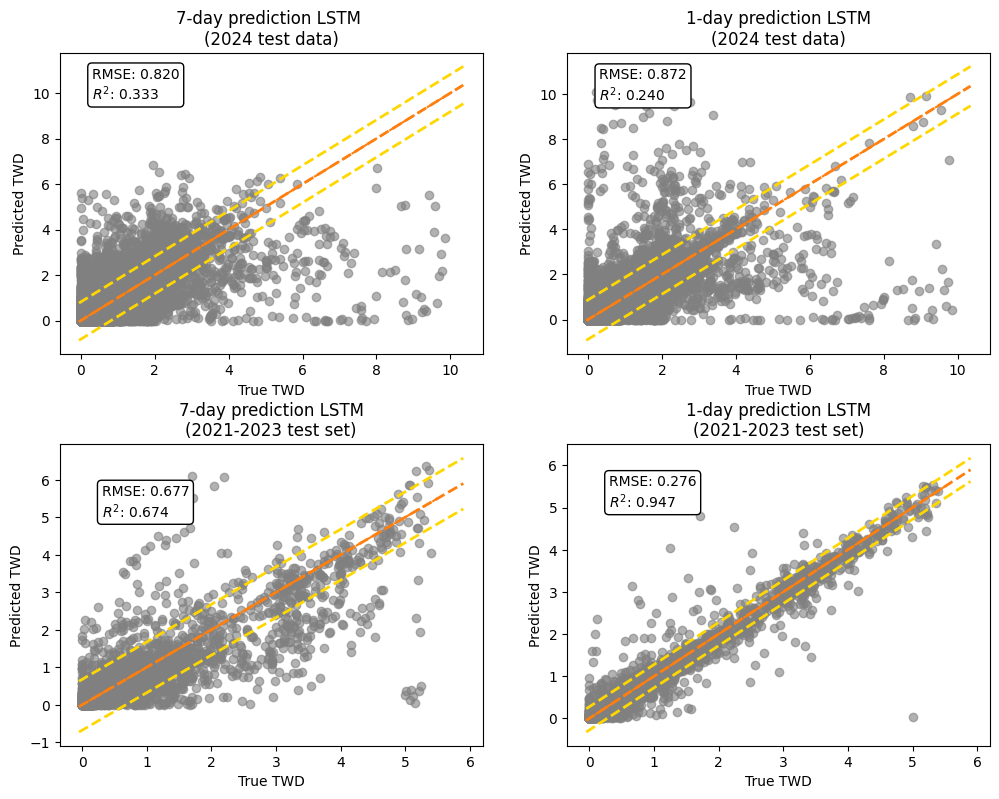

In [31]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 9))

fig.subplots_adjust(wspace=0.2, hspace=0.3)
x_range_final_test = [y_true_1day_final.min()-0.05, y_true_1day_final.max()+0.5]
x_range_test = [y_test_1day.min()-0.05, y_test_1day.max()+0.5]

ax1.scatter(test_y_final_at_recursive, test_y_pred_final_at ,  color = "grey", alpha=0.6)
ax1.plot(x_range_final_test, x_range_final_test, color="tab:orange", linestyle="--")
ax1.text(0.3, 9.7, f"RMSE: {rmse_test_at_final:.3f}\n$R^{2}$: {r2_test_at_final:.3f}",
 fontsize=10, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
ax1.plot(x_range_final_test, x_range_final_test, 'k--', lw=2, color="tab:orange")
ax1.plot(x_range_final_test, [i+rmse_test_at_final for i in x_range_final_test], 'k--', lw=2, color="gold")
ax1.plot(x_range_final_test, [i-rmse_test_at_final for i in x_range_final_test], 'k--', lw=2, color="gold")
ax1.set_xlabel("True TWD")
ax1.set_ylabel("Predicted TWD")
ax1.set_title("7-day prediction LSTM \n(2024 test data)")


ax2.scatter(y_true_1day_final, y_pred_1day_final,color = "grey", alpha=0.6)
ax2.plot(x_range_final_test, x_range_final_test, color="tab:orange", linestyle="--")
ax2.text(0.3, 9.7,f"RMSE: {rmse_1day_final:.3f}\n$R^{2}$: {r2_1day_final:.3f}",
 fontsize=10, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
ax2.plot(x_range_final_test, x_range_final_test, 'k--', lw=2, color="tab:orange")
ax2.plot(x_range_final_test, [i+rmse_1day_final for i in x_range_final_test], 'k--', lw=2, color="gold")
ax2.plot(x_range_final_test, [i-rmse_1day_final for i in x_range_final_test], 'k--', lw=2, color="gold")
ax2.set_xlabel("True TWD")
ax2.set_ylabel("Predicted TWD")
ax2.set_title("1-day prediction LSTM\n(2024 test data)")

ax3.scatter(y_test_at, y_pred_test_at,color = "grey", alpha=0.6)
ax3.plot([-0.05, 5.5], [-0.05, 5.5], color="tab:orange", linestyle="--")
ax3.text(0.3, 5, f"RMSE: {rmse_at_test:.3f}\n$R^{2}$: {r2_at_test:.3f}",
 fontsize=10, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
ax3.plot(x_range_test, x_range_test, 'k--', lw=2, color="tab:orange")
ax3.plot(x_range_test, [i+rmse_at_test for i in x_range_test], 'k--', lw=2, color="gold")
ax3.plot(x_range_test, [i-rmse_at_test for i in x_range_test], 'k--', lw=2, color="gold")
ax3.set_xlabel("True TWD")
ax3.set_ylabel("Predicted TWD")
ax3.set_title("7-day prediction LSTM\n(2021-2023 test set)")

ax4.scatter(y_test_1day, y_pred_test_1day,color = "grey", alpha=0.6)
ax4.plot([-0.05, 5.5], [-0.05, 5.5], color="tab:orange", linestyle="--")
ax4.text(0.3, 5, f"RMSE: {rmse_test_1day:.3f}\n$R^{2}$: {r2_test_1day:.3f}",
 fontsize=10, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
ax4.plot(x_range_test, x_range_test, 'k--', lw=2, color="tab:orange")
ax4.plot(x_range_test, [i+rmse_test_1day for i in x_range_test], 'k--', lw=2, color="gold")
ax4.plot(x_range_test, [i-rmse_test_1day for i in x_range_test], 'k--', lw=2, color="gold")
ax4.set_xlabel("True TWD")
ax4.set_ylabel("Predicted TWD")
ax4.set_title("1-day prediction LSTM\n(2021-2023 test set)")

0.8438446083779824
0.29322232763552236


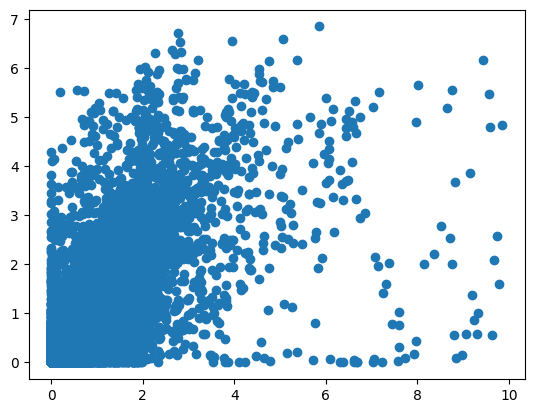

In [26]:

print(rmse_test_at_final)
print(r2_test_at_final)

plt.scatter(test_y_final_at_recursive, test_y_pred_final_at)

0.8927108645439148 0.20396912097930908


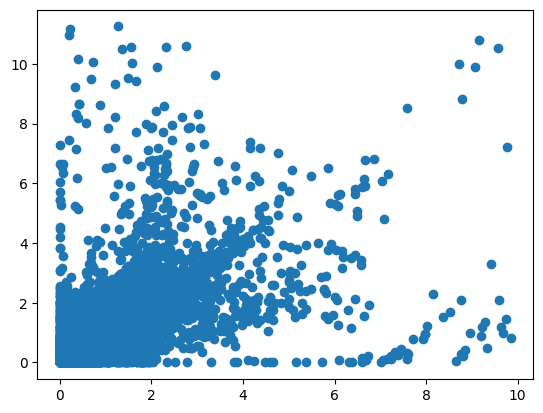

In [27]:
plt.scatter(y_true_1day_final , y_pred_1day_final)


print(rmse_1day_final, r2_1day_final)

In [24]:
df_series_all_test.loc[df_series_all_test["twd"]>5, ].species.value_counts()

species
Picea abies              66
Pseudotsuga menziesii    55
Name: count, dtype: int64

(array([3.9467e+04, 4.0950e+03, 1.5650e+03, 6.3500e+02, 1.5900e+02,
        9.3000e+01, 1.1000e+01, 5.0000e+00, 1.0000e+00, 1.0000e+00]),
 array([-3.25838725e-05,  2.66864118e-01,  5.33760820e-01,  8.00657522e-01,
         1.06755422e+00,  1.33445093e+00,  1.60134763e+00,  1.86824433e+00,
         2.13514103e+00,  2.40203773e+00,  2.66893444e+00]),
 <BarContainer object of 10 artists>)

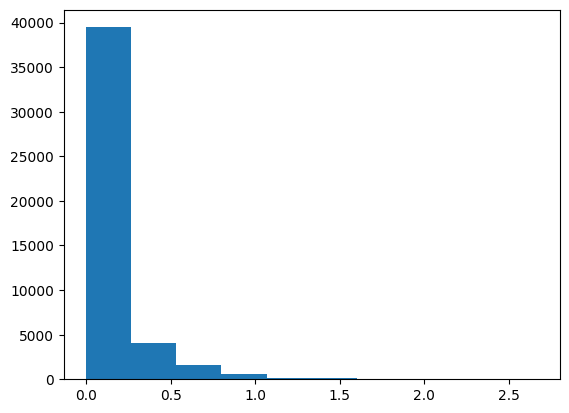

In [28]:
plt.hist(df_series_all.pr )

(array([1.1156e+04, 1.3960e+03, 6.4200e+02, 1.8400e+02, 1.0900e+02,
        5.9000e+01, 6.0000e+00, 2.0000e+00, 0.0000e+00, 8.0000e+00]),
 array([-2.80611445e-05,  2.65129166e-01,  5.30286394e-01,  7.95443621e-01,
         1.06060085e+00,  1.32575808e+00,  1.59091530e+00,  1.85607253e+00,
         2.12122976e+00,  2.38638699e+00,  2.65154421e+00]),
 <BarContainer object of 10 artists>)

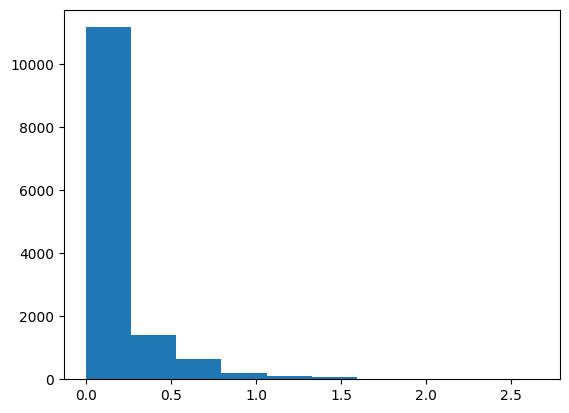

In [27]:
plt.hist(df_series_all_test.pr )

In [30]:
df_series_all_test.loc[df_series_all_test["twd"]>5, ].site_name.value_counts()

df_series_all_test.loc[df_series_all_test["twd"]>5, ].groupby(["species", "site_name"]).count()

ts  twd  pr  at  ws  dp  sr  lr  \
species               site_name                                                
Picea abies           Davos-Seehornwald      21   21  21  21  21  21  21  21   
                      Hohtenn-Gampel-Forest  21   21  21  21  21  21  21  21   
                      Schmitten-Forest       24   24  24  24  24  24  24  24   
Pseudotsuga menziesii Muri-Forest            55   55  55  55  55  55  55  55   

                                             series  series_no  Wt  year  \
species               site_name                                            
Picea abies           Davos-Seehornwald          21         21  21    21   
                      Hohtenn-Gampel-Forest      21         21  21    21   
                      Schmitten-Forest           24         24  24    24   
Pseudotsuga menziesii Muri-Forest                55         55  55    55   

                                             month  year_month  
species               site_name                                 
Picea abies           Davos-Seehornwald         21          21  
                      Hohtenn-Gampel-Forest     21          21  
                      Schmitten-Forest          24          24  
Pseudotsuga menziesii Muri-Forest               55          55

In [31]:
df_series_all.groupby(["species", "site_name"]).count()

ts   twd    pr    at  \
species               site_name                                              
Carpinus betulus      Bursins-Forest                4384  4384  4384  4384   
Corylus avellana      Choeliacher-Orchard           2192  2192  2192  2192   
Fagus sylvatica       Bachtel-Forest                1096  1096  1096  1096   
                      Genolier-Forest               3288  3288  3288  3288   
                      Neunkirch-North               2192  2192  2192  2192   
                      Neunkirch-Southwest           1096  1096  1096  1096   
                      Saillon-A860                  1096  1096  1096  1096   
                      Schaenis-low                  1096  1096  1096  1096   
                      Sihlwald-Forest               1096  1096  1096  1096   
Picea abies           Davos-Seehornwald             3288  3288  3288  3288   
                      Hohtenn-Gampel-Forest         2192  2192  2192  2192   
                      Laegeren-Hut                  1096  1096  1096  1096   
                      Pfynwald-Illgraben-Northwest  2192  2192  2192  2192   
                      Schmitten-Forest              7672  7672  7672  7672   
Pinus sylvestris      Lens-Forest                   1096  1096  1096  1096   
                      Pfynwald-Control              1096  1096  1096  1096   
                      Pfynwald-Irrigation           3288  3288  3288  3288   
Pseudotsuga menziesii Muri-Forest                   2192  2192  2192  2192   
Quercus petraea       Bueren-Forest                 2192  2192  2192  2192   
                      Neunkirch-Southeast           2192  2192  2192  2192   

                                                      ws    dp    sr    lr  \
species               site_name                                              
Carpinus betulus      Bursins-Forest                4384  4384  4384  4384   
Corylus avellana      Choeliacher-Orchard           2192  2192  2192  2192   
Fagus sylvatica       Bachtel-Forest                1096  1096  1096  1096   
                      Genolier-Forest               3288  3288  3288  3288   
                      Neunkirch-North               2192  2192  2192  2192   
                      Neunkirch-Southwest           1096  1096  1096  1096   
                      Saillon-A860                  1096  1096  1096  1096   
                      Schaenis-low                  1096  1096  1096  1096   
                      Sihlwald-Forest               1096  1096  1096  1096   
Picea abies           Davos-Seehornwald             3288  3288  3288  3288   
                      Hohtenn-Gampel-Forest         2192  2192  2192  2192   
                      Laegeren-Hut                  1096  1096  1096  1096   
                      Pfynwald-Illgraben-Northwest  2192  2192  2192  2192   
                      Schmitten-Forest              7672  7672  7672  7672   
Pinus sylvestris      Lens-Forest                   1096  1096  1096  1096   
                      Pfynwald-Control              1096  1096  1096  1096   
                      Pfynwald-Irrigation           3288  3288  3288  3288   
Pseudotsuga menziesii Muri-Forest                   2192  2192  2192  2192   
Quercus petraea       Bueren-Forest                 2192  2192  2192  2192   
                      Neunkirch-Southeast           2192  2192  2192  2192   

                                                    series  series_no    Wt  \
species               site_name                                               
Carpinus betulus      Bursins-Forest                  4384       4384  4380   
Corylus avellana      Choeliacher-Orchard             2192       2192  2190   
Fagus sylvatica       Bachtel-Forest                  1096       1096  1095   
                      Genolier-Forest                 3288       3288  3285   
                      Neunkirch-North                 2192       2192  2190   
                      Neunkirch-Southwest             1096       10